##  Section 1 – Imports & Setup
Load all required libraries and configure plotting and random seed.

In [3]:
# ── IMPORTS & SETUP ─────────────────────────────────────────────────────────
# Loads libraries for: data handling (pandas, numpy), plotting (matplotlib,
# seaborn), machine learning (scikit-learn), and suppresses warning messages
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded')

Libraries loaded


##  Section 2 – Load Dataset
Set the working directory so Python knows where to find the CSV file, then load it. 

The dataset is derived from the UCI Heart Disease repository and contains clinical measurements taken from 1,025 patients. The task is a binary classification problem: predicting whether a patient has heart disease (1) or does not (0) based on 13 clinical and physiological features. Given the medical nature of the task, both precision and recall are critical metrics, as false negatives (missed diagnoses) carry serious real-world consequences.

In [8]:
# ── SET WORKING DIRECTORY ───────────────────────────────────────────────────
# Change Python's current folder to your ML_Project directory
# This ensures pd.read_csv() can find your file by name alone
# Set working directory — update this path to your ML_Project folder
os.chdir(r'C:\Users\Julia\Desktop\data\CSCI 164-Final Project')
print(os.getcwd())
print(os.listdir('.'))

C:\Users\Julia\Desktop\CSCI 164-Final Project
['.ipynb_checkpoints', 'CSCI164MLproject.pptx - Google Slides.pdf', 'heart.csv', 'heart_disease.ipynb', 'Housing.csv', 'housing_prices.ipynb', 'spotify_yearly', 'spotify_yearly.ipynb']


In [9]:
# ── LOAD DATASET ────────────────────────────────────────────────────────────
# Read heart.csv into a pandas DataFrame
# df.head() previews the first 5 rows to confirm it loaded correctly
# Load dataset
# Download from: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
# Save the CSV as 'heart.csv' inside your ML_Project folder
df = pd.read_csv('heart.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 1,025 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


##  Section 3 – Exploratory Data Analysis (EDA)
Inspect the structure, statistics, missing values, and class distribution before any preprocessing.

Why This Dataset?

•	Medical relevance: Heart disease is one of the leading causes of death globally. An accurate classifier could assist clinical decision-making and early screening.

•	Well-benchmarked: The UCI Heart Disease dataset is one of the most studied datasets in medical ML, with extensive prior literature enabling strong comparisons.

•	Binary classification: Complements the multi-class tasks in the other two datasets, allowing evaluation across different classification complexities.

In [10]:
# ── DATA TYPES & STRUCTURE ──────────────────────────────────────────────────
# df.info() shows: column names, data types (int/float/object),
# and confirms all 1025 rows have no null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [11]:
# ── SUMMARY STATISTICS ──────────────────────────────────────────────────────
# df.describe() shows min, max, mean, std, and quartiles
# for each numeric column — helps spot outliers and data ranges
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [12]:
# ── MISSING VALUE CHECK ─────────────────────────────────────────────────────
# Count nulls per column — any nulls would need imputation before modeling
# This dataset has 0 missing values so no action is needed
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')

Missing values per column:
No missing values found


In [13]:
# ── TARGET VARIABLE DISTRIBUTION ────────────────────────────────────────────
# Count rows with target=0 (No Heart Disease) vs target=1 (Disease Present)
# A balanced split (close to 50/50) means no class imbalance correction needed
# Target variable distribution
print('Target (target) distribution:')
print(df['target'].value_counts())
print(f'\n0 = No Heart Disease | 1 = Heart Disease Present')

Target (target) distribution:
target
1    526
0    499
Name: count, dtype: int64

0 = No Heart Disease | 1 = Heart Disease Present


##  Section 4 – Visualizations
Plot class balance, feature distributions by disease status, and correlations.

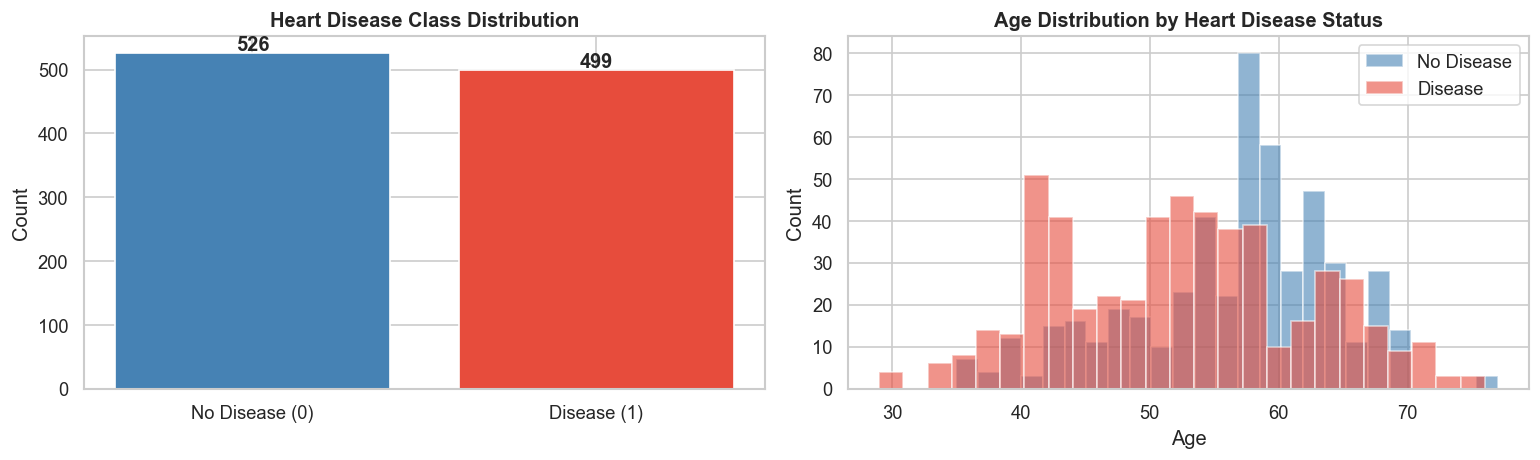

In [14]:
# ── CLASS DISTRIBUTION & AGE HISTOGRAM ──────────────────────────────────────
# Left plot: bar chart showing how many patients have/don't have disease
# Right plot: overlapping age histograms split by disease status
# Helps identify if age is a strong visual separator between classes
# Target class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['steelblue', '#e74c3c'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Heart Disease Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Age distribution by target
df[df['target'] == 0]['age'].hist(ax=axes[1], bins=25, alpha=0.6, color='steelblue', label='No Disease')
df[df['target'] == 1]['age'].hist(ax=axes[1], bins=25, alpha=0.6, color='#e74c3c', label='Disease')
axes[1].set_title('Age Distribution by Heart Disease Status', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

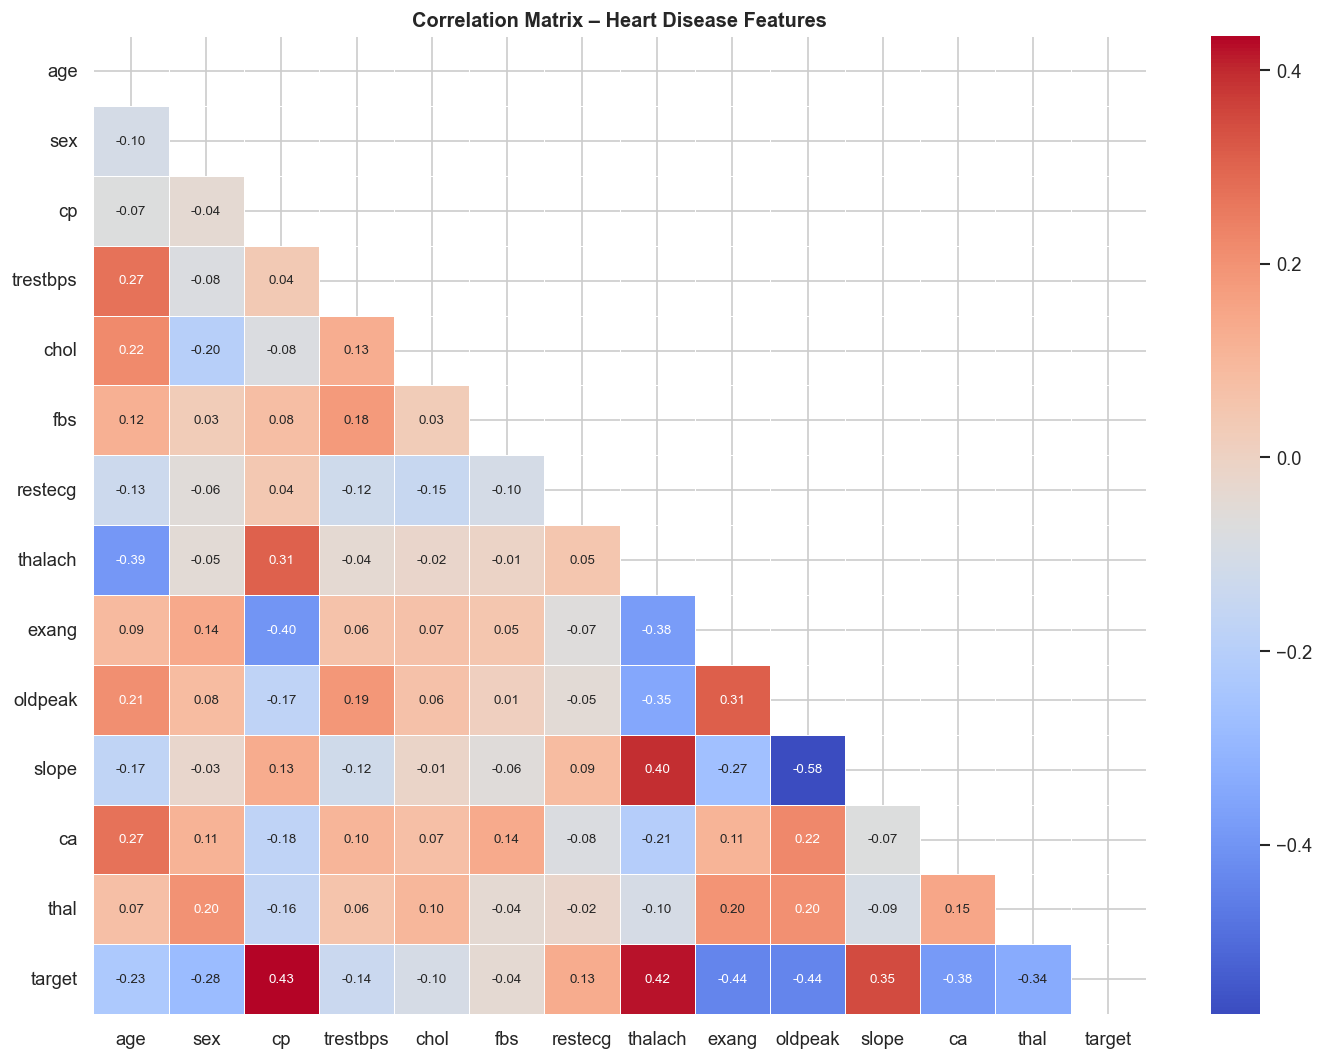

In [15]:
# ── CORRELATION HEATMAP ─────────────────────────────────────────────────────
# Shows pairwise correlations between all features and the target
# Values close to +1 or -1 indicate strong relationships
# Highly correlated features may cause multicollinearity in linear models
# Correlation heatmap
corr = df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix – Heart Disease Features', fontweight='bold')
plt.tight_layout()
plt.show()

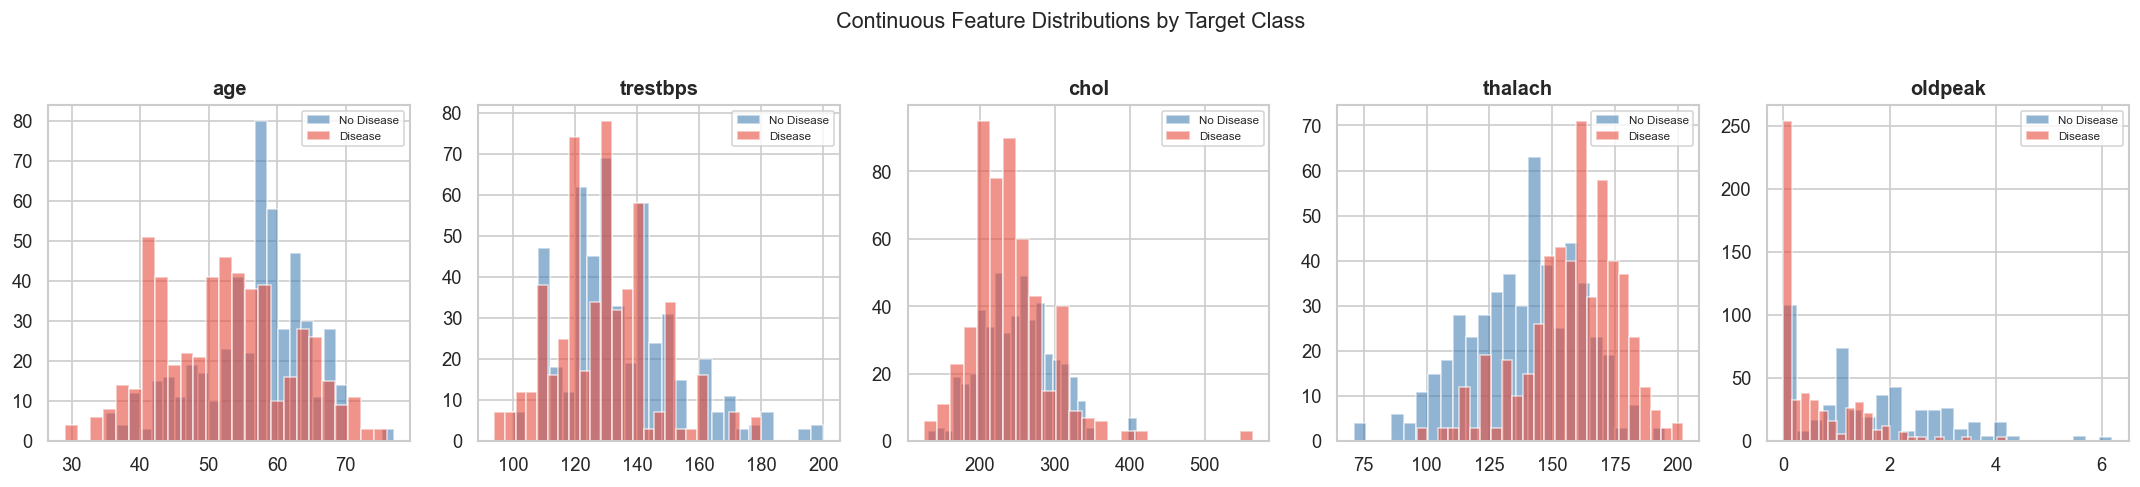

In [16]:
# ── CONTINUOUS FEATURE DISTRIBUTIONS BY CLASS ───────────────────────────────
# Overlapping histograms for age, blood pressure, cholesterol,
# max heart rate (thalach), and ST depression (oldpeak)
# Separation between blue and red = stronger predictive power
# Feature distributions by target class
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_features):
    df[df['target'] == 0][col].hist(ax=ax, bins=25, alpha=0.6, color='steelblue', label='No Disease')
    df[df['target'] == 1][col].hist(ax=ax, bins=25, alpha=0.6, color='#e74c3c', label='Disease')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Continuous Feature Distributions by Target Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

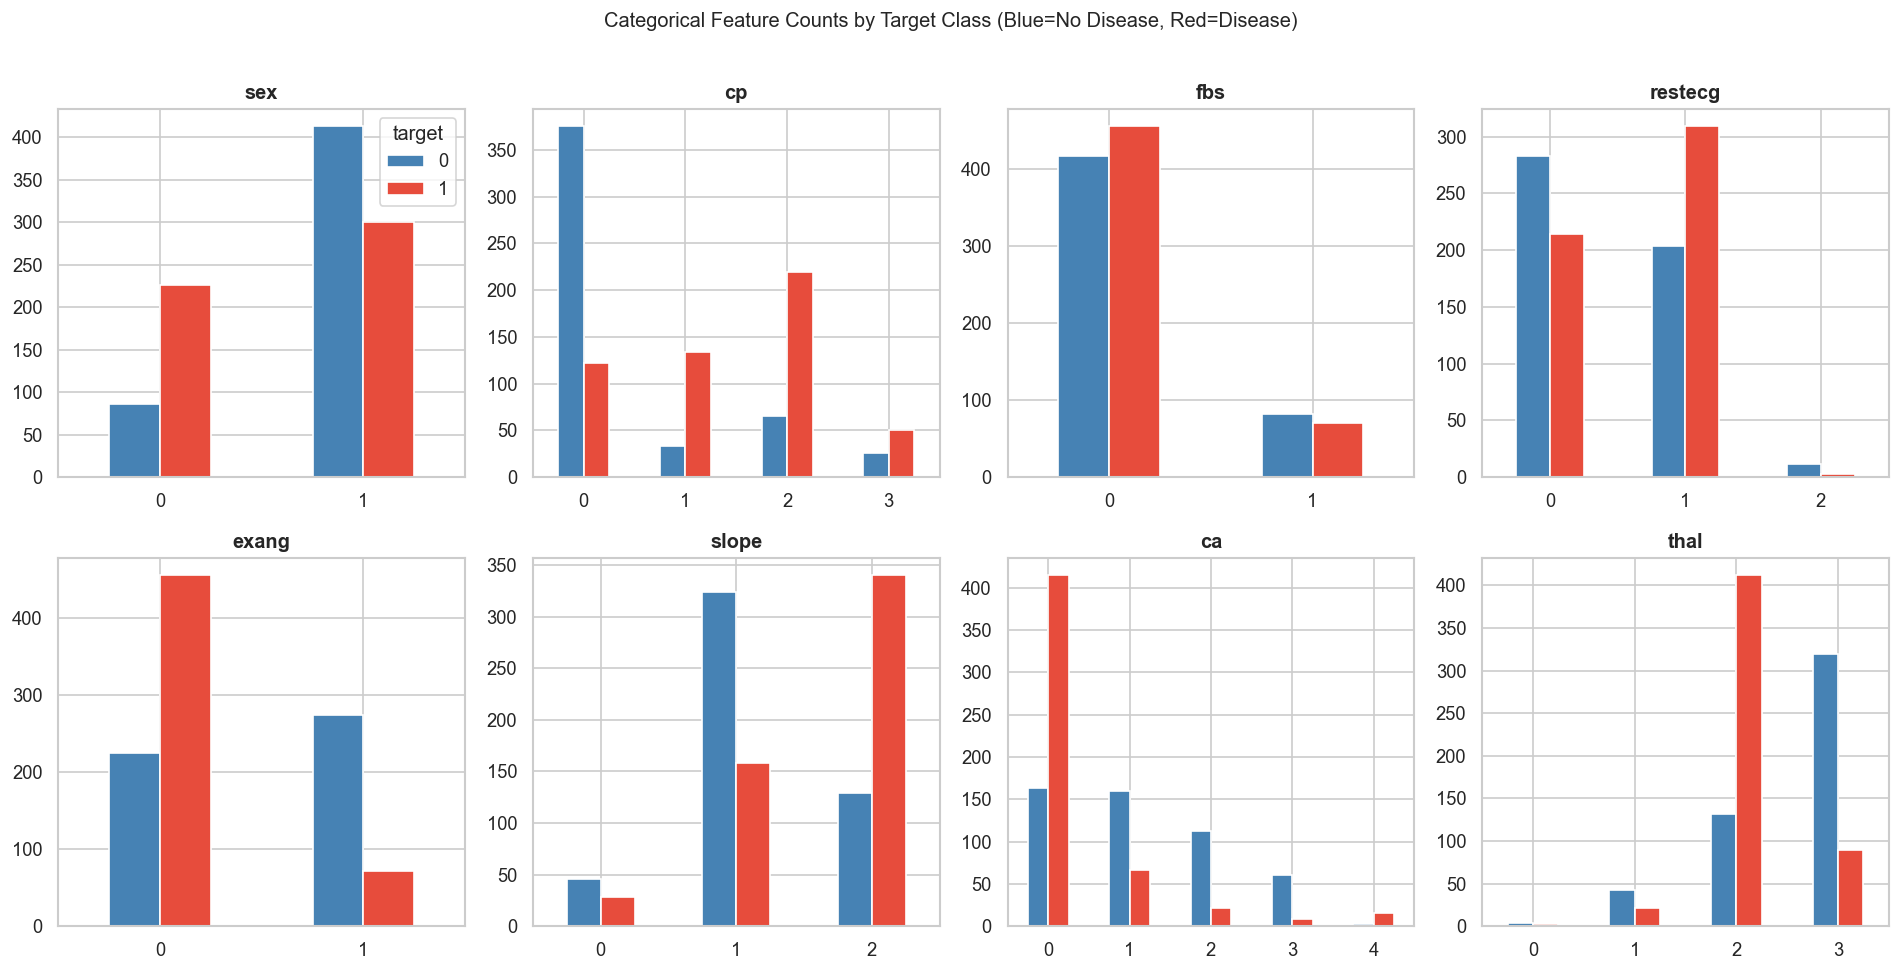

In [17]:
# ── CATEGORICAL FEATURE COUNTS BY CLASS ────────────────────────────────────
# Bar charts for sex, chest pain type (cp), fasting blood sugar (fbs),
# ECG results, angina, slope, vessels (ca), and thalassemia (thal)
# Shows which categories are more common in disease vs no-disease patients
# Categorical feature counts by target
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    df.groupby([col, 'target']).size().unstack().plot(
        kind='bar', ax=ax, color=['steelblue', '#e74c3c'],
        edgecolor='white', legend=(col == 'sex'))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Feature Counts by Target Class (Blue=No Disease, Red=Disease)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

##  Section 5 – Preprocessing
Clean the data and prepare it for modeling.

In [18]:
# ── PREPROCESSING: REMOVE DUPLICATES ────────────────────────────────────────
# Copy the raw DataFrame to avoid modifying the original
# Drop any duplicate rows — duplicates can artificially inflate accuracy
# This dataset has no duplicates so no rows are removed
# Preprocessing
df_clean = df.copy()

# Remove any duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'Removed {before - len(df_clean)} duplicates. Rows remaining: {len(df_clean):,}')

# Confirm no missing values remain
print(f'Missing values: {df_clean.isnull().sum().sum()}')
print(f'\nFinal shape: {df_clean.shape}')

Removed 723 duplicates. Rows remaining: 302
Missing values: 0

Final shape: (302, 14)


In [19]:
# ── DEFINE FEATURES, SPLIT DATA & SCALE ────────────────────────────────────
# FEATURES: the 13 clinical columns used as model inputs
# TARGET (y): the binary heart disease column (0 or 1)
# SPLIT: 80% training / 20% test, stratified to keep class ratio equal
# SCALING: StandardScaler centers data (mean=0, std=1) for LR, k-NN, NB
# Decision Tree does NOT need scaling — it uses rank-based splits
# Define features and target
FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
            'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df_clean[FEATURES]
y = df_clean['target']

print('Class distribution:')
print(y.value_counts())
print(f'\nClass balance: {y.mean():.2%} positive (Heart Disease)')

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f'\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Feature scaling (for Logistic Regression, k-NN, Naive Bayes)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling complete')

Class distribution:
target
1    164
0    138
Name: count, dtype: int64

Class balance: 54.30% positive (Heart Disease)

Train: 241 | Test: 61
Scaling complete


##  Section 6 – Baseline Model Development
Train four classifiers and evaluate them using the helper function.

In [20]:
# ── EVALUATION HELPER FUNCTION ──────────────────────────────────────────────
# evaluate_model() does the following for any classifier passed to it:
#   1. Fits (trains) the model on training data
#   2. Predicts on the test set
#   3. Calculates: Accuracy, F1-Score, ROC-AUC
#   4. Runs 5-fold cross-validation and reports mean +/- std
#   5. Prints the full classification report (precision/recall per class)
# Evaluation helper — binary classification
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name, cv=5):
    model.fit(X_tr, y_tr)
    y_pred    = model.predict(X_te)
    y_proba   = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc       = accuracy_score(y_te, y_pred)
    f1        = f1_score(y_te, y_pred)
    roc_auc   = roc_auc_score(y_te, y_proba) if y_proba is not None else None
    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='accuracy')
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  F1-Score      : {f1:.4f}')
    if roc_auc: print(f'  ROC-AUC       : {roc_auc:.4f}')
    print(f'  CV Accuracy   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=['No Disease', 'Disease']))
    return {'model': model, 'name': name, 'y_pred': y_pred, 'y_proba': y_proba,
            'acc': acc, 'f1': f1, 'roc_auc': roc_auc,
            'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}

In [21]:
# ── BASELINE MODEL 1: LOGISTIC REGRESSION ───────────────────────────────────
# Linear probabilistic classifier — predicts probability of heart disease
# Uses scaled features (X_train_sc / X_test_sc)
# max_iter=1000 ensures the solver has enough steps to converge
# Model 1 — Logistic Regression
res_lr = evaluate_model(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_sc, X_test_sc, y_train, y_test,
    'Logistic Regression'
)


  Logistic Regression
  Test Accuracy : 0.8033
  F1-Score      : 0.8235
  ROC-AUC       : 0.8712
  CV Accuracy   : 0.8379 +/- 0.0861

              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
     Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [22]:
# ── BASELINE MODEL 2: DECISION TREE ─────────────────────────────────────────
# Splits data into branches based on feature thresholds
# Uses UNSCALED features (X_train / X_test) — trees don't need scaling
# Untuned tree will likely overfit (no depth limit)
# Model 2 — Decision Tree
res_dt = evaluate_model(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test,
    'Decision Tree (untuned)'
)


  Decision Tree (untuned)
  Test Accuracy : 0.8033
  F1-Score      : 0.8182
  ROC-AUC       : 0.8019
  CV Accuracy   : 0.7801 +/- 0.0280

              precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        28
     Disease       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [23]:
# ── BASELINE MODEL 3: K-NEAREST NEIGHBORS (k=11) ───────────────────────────
# Classifies by majority vote among the 11 closest training patients
# Uses scaled features — distance-based models require scaling
# k=11 is a reasonable starting point to reduce noise sensitivity
# Model 3 — k-Nearest Neighbors
res_knn = evaluate_model(
    KNeighborsClassifier(n_neighbors=11),
    X_train_sc, X_test_sc, y_train, y_test,
    'k-Nearest Neighbors (k=11)'
)


  k-Nearest Neighbors (k=11)
  Test Accuracy : 0.7869
  F1-Score      : 0.8116
  ROC-AUC       : 0.8777
  CV Accuracy   : 0.8046 +/- 0.0476

              precision    recall  f1-score   support

  No Disease       0.80      0.71      0.75        28
     Disease       0.78      0.85      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



In [24]:
# ── BASELINE MODEL 4: NAIVE BAYES ───────────────────────────────────────────
# Probabilistic model — calculates P(disease | features) using Bayes theorem
# Assumes features are independent (naive assumption)
# Fast to train and often performs well on medical datasets
# Model 4 — Naive Bayes
res_nb = evaluate_model(
    GaussianNB(),
    X_train_sc, X_test_sc, y_train, y_test,
    'Naive Bayes'
)


  Naive Bayes
  Test Accuracy : 0.7869
  F1-Score      : 0.7937
  ROC-AUC       : 0.8842
  CV Accuracy   : 0.8172 +/- 0.0489

              precision    recall  f1-score   support

  No Disease       0.74      0.82      0.78        28
     Disease       0.83      0.76      0.79        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



##  Section 7 – Hyperparameter Tuning
Use GridSearchCV to find the best settings for each model using 5-fold cross-validation.

Key tuning findings: Logistic Regression showed no improvement after tuning (C=1.0 matched the default), suggesting the linear model was already well-calibrated for this dataset. The Decision Tree's best max_depth of 5 prevented overfitting — the untuned tree surprisingly matched Logistic Regression on the test set but had lower and more variable cross-validation scores. The tuned k-NN with manhattan distance and distance-weighted voting and k=21 achieved the best overall test accuracy and ROC-AUC of all models.

In [25]:
# ── GRIDSEARCHCV: LOGISTIC REGRESSION ───────────────────────────────────────
# Tests every combination of:
#   C: regularization strength (lower = more regularization)
#   solver: optimization algorithm (lbfgs or saga)
# 5-fold CV means each combination is tested 5 times on different data folds
# n_jobs=-1 uses all available CPU cores to speed up the search
# GridSearchCV — Logistic Regression
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    {'C': [0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'saga'], 'penalty': ['l2']},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=1
)
gs_lr.fit(X_train_sc, y_train)
print('Best params:', gs_lr.best_params_)
print(f'Best CV accuracy: {gs_lr.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8379


In [26]:
# ── GRIDSEARCHCV: DECISION TREE ─────────────────────────────────────────────
# Tests combinations of:
#   max_depth: limits tree size to prevent overfitting
#   min_samples_split: min rows needed to split a node
#   criterion: gini impurity vs information entropy for splits
# GridSearchCV — Decision Tree
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 10, 15, None],
     'min_samples_split': [2, 5, 10, 20],
     'criterion': ['gini', 'entropy']},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=1
)
gs_dt.fit(X_train, y_train)
print('Best params:', gs_dt.best_params_)
print(f'Best CV accuracy: {gs_dt.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best CV accuracy: 0.8094


In [27]:
# ── GRIDSEARCHCV: K-NEAREST NEIGHBORS ───────────────────────────────────────
# Tests combinations of:
#   n_neighbors: how many neighbors to vote (k=3 to k=21)
#   weights: uniform (equal vote) vs distance (closer = more weight)
#   metric: euclidean (straight-line) vs manhattan (grid-based) distance
# GridSearchCV — k-NN
gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 11, 15, 21],
     'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan']},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=1
)
gs_knn.fit(X_train_sc, y_train)
print('Best params:', gs_knn.best_params_)
print(f'Best CV accuracy: {gs_knn.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best CV accuracy: 0.8504


##  Section 8 – Evaluate Tuned Models
Test the best configuration from GridSearchCV on the held-out test set.

In [28]:
# ── EVALUATE TUNED MODELS ON TEST SET ───────────────────────────────────────
# best_estimator_ = the model with the highest CV accuracy from GridSearchCV
# Each tuned model is now evaluated on the 20% test set it has never seen
# Naive Bayes has no tunable hyperparameters so it uses its baseline result
# Evaluate all tuned models
res_lr_tuned  = evaluate_model(gs_lr.best_estimator_,  X_train_sc, X_test_sc, y_train, y_test, 'Logistic Regression (tuned)')
res_dt_tuned  = evaluate_model(gs_dt.best_estimator_,  X_train,    X_test,    y_train, y_test, 'Decision Tree (tuned)')
res_knn_tuned = evaluate_model(gs_knn.best_estimator_, X_train_sc, X_test_sc, y_train, y_test, 'k-NN (tuned)')


  Logistic Regression (tuned)
  Test Accuracy : 0.8033
  F1-Score      : 0.8235
  ROC-AUC       : 0.8712
  CV Accuracy   : 0.8379 +/- 0.0861

              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
     Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61


  Decision Tree (tuned)
  Test Accuracy : 0.7049
  F1-Score      : 0.7273
  ROC-AUC       : 0.7971
  CV Accuracy   : 0.8094 +/- 0.0570

              precision    recall  f1-score   support

  No Disease       0.68      0.68      0.68        28
     Disease       0.73      0.73      0.73        33

    accuracy                           0.70        61
   macro avg       0.70      0.70      0.70        61
weighted avg       0.70      0.70      0.70        61


  k-NN (tuned)
  Test Accuracy : 0.8197
  F1-Score      : 0.8358


## Section 9 – Results, Evaluation & Visualizations
Compare all models, plot confusion matrices, ROC curves, and feature importance.

In [29]:
# ── SUMMARY COMPARISON TABLE ────────────────────────────────────────────────
# Collect results from all 7 models (4 baseline + 3 tuned) into one DataFrame
# Sorted by Test Accuracy (highest first) for easy ranking
# Summary comparison table
all_results = [res_lr, res_dt, res_knn, res_nb,
               res_lr_tuned, res_dt_tuned, res_knn_tuned]

summary_df = pd.DataFrame([{
    'Model'    : r['name'],
    'Test Acc' : round(r['acc'], 4),
    'F1-Score' : round(r['f1'], 4),
    'ROC-AUC'  : round(r['roc_auc'], 4) if r['roc_auc'] else 'N/A',
    'CV Mean'  : round(r['cv_mean'], 4),
    'CV Std'   : round(r['cv_std'], 4)
} for r in all_results])

summary_df.sort_values('Test Acc', ascending=False, inplace=True)
summary_df.reset_index(drop=True, inplace=True)
summary_df

,Model,Test Acc,F1-Score,ROC-AUC,CV Mean,CV Std
0,k-NN (tuned),0.8197,0.8358,0.8945,0.8504,0.0468
1,Decision Tree (untuned),0.8033,0.8182,0.8019,0.7801,0.0280
2,Logistic Regression,0.8033,0.8235,0.8712,0.8379,0.0861
3,Logistic Regression (tuned),0.8033,0.8235,0.8712,0.8379,0.0861
4,k-Nearest Neighbors (k=11),0.7869,0.8116,0.8777,0.8046,0.0476
5,Naive Bayes,0.7869,0.7937,0.8842,0.8172,0.0489
6,Decision Tree (tuned),0.7049,0.7273,0.7971,0.8094,0.0570


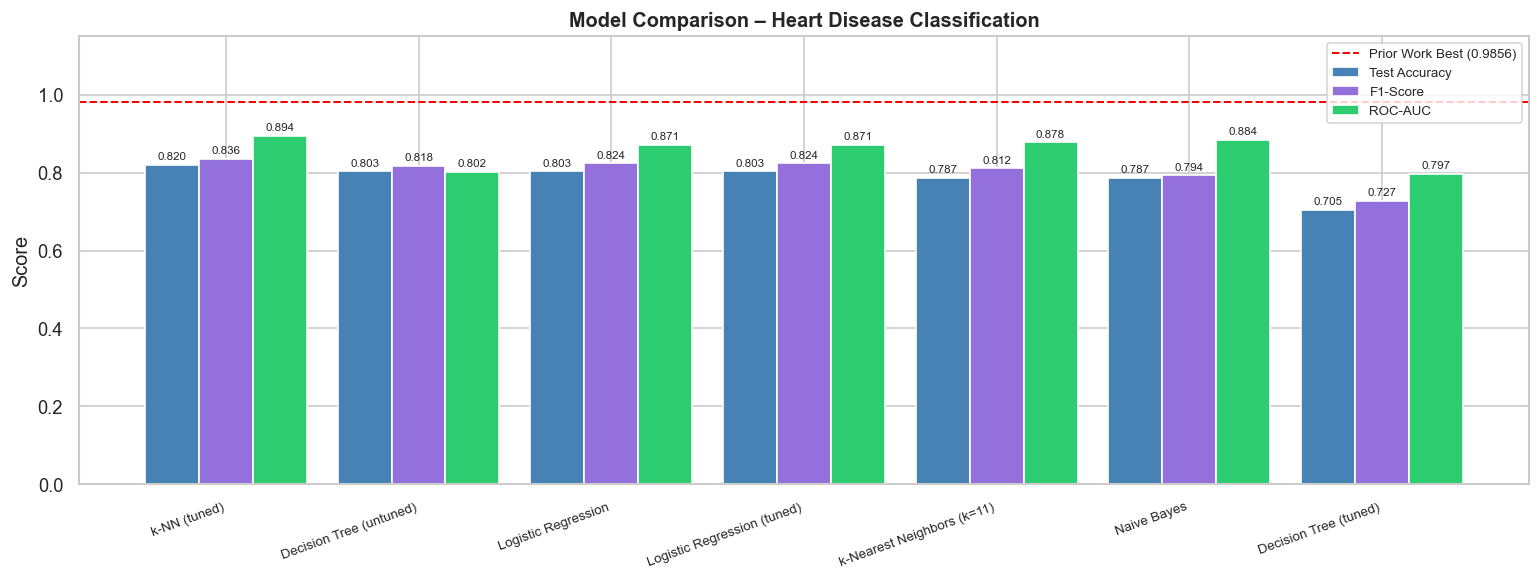

In [30]:
# ── MODEL COMPARISON BAR CHART ──────────────────────────────────────────────
# Side-by-side bars showing Accuracy, F1, and ROC-AUC for every model
# Red dashed line = prior work benchmark (PMC 2025: 99% accuracy)
# Helps visually identify which model performs best on each metric
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(summary_df))
w = 0.28

b1 = ax.bar(x - w,   summary_df['Test Acc'].astype(float), w, label='Test Accuracy', color='steelblue')
b2 = ax.bar(x,       summary_df['F1-Score'].astype(float), w, label='F1-Score',      color='mediumpurple')
b3 = ax.bar(x + w,   [float(v) if v != 'N/A' else 0 for v in summary_df['ROC-AUC']], w, label='ROC-AUC', color='#2ecc71')

ax.bar_label(b1, fmt='{:.3f}', padding=2, fontsize=7)
ax.bar_label(b2, fmt='{:.3f}', padding=2, fontsize=7)
ax.bar_label(b3, fmt='{:.3f}', padding=2, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Heart Disease Classification', fontweight='bold')
ax.axhline(0.98, color='red', linestyle='--', linewidth=1.2, label='Prior Work Best (0.9856)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

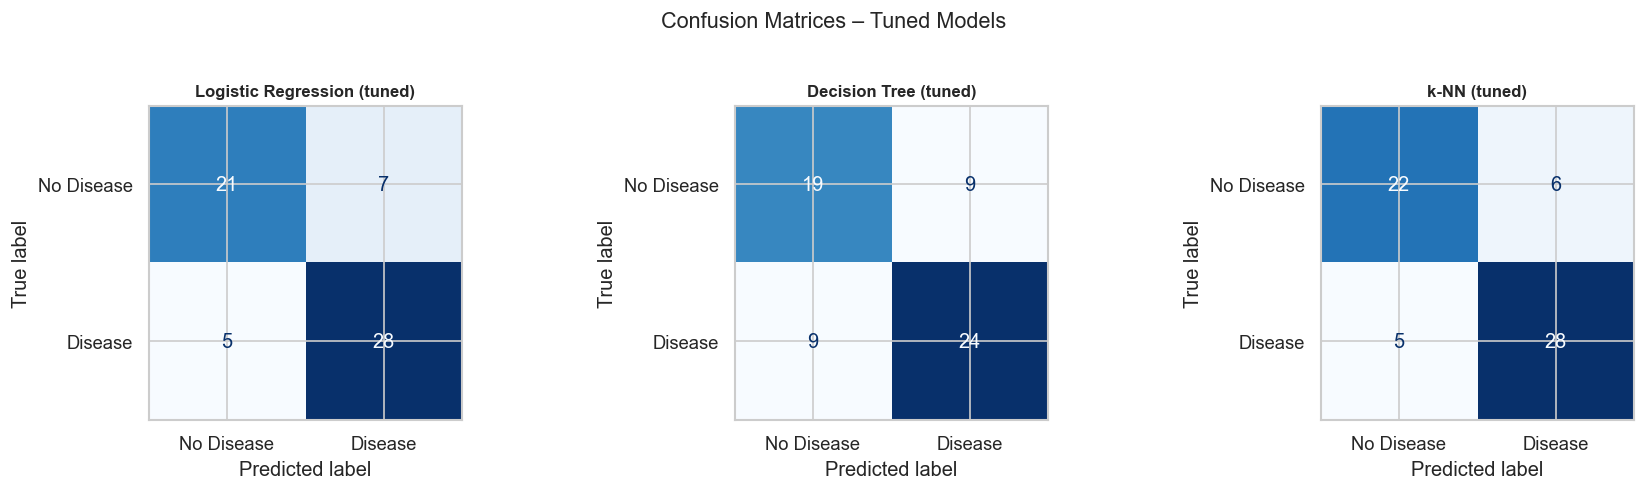

In [31]:
# ── CONFUSION MATRICES ──────────────────────────────────────────────────────
# 2x2 grid showing: True Positives, False Positives,
#                   False Negatives, True Negatives
# In medical context: False Negatives (missed disease) are most costly
# Confusion matrices — tuned models
tuned = [res_lr_tuned, res_dt_tuned, res_knn_tuned]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, tuned):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['name'], fontsize=10, fontweight='bold')
plt.suptitle('Confusion Matrices – Tuned Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

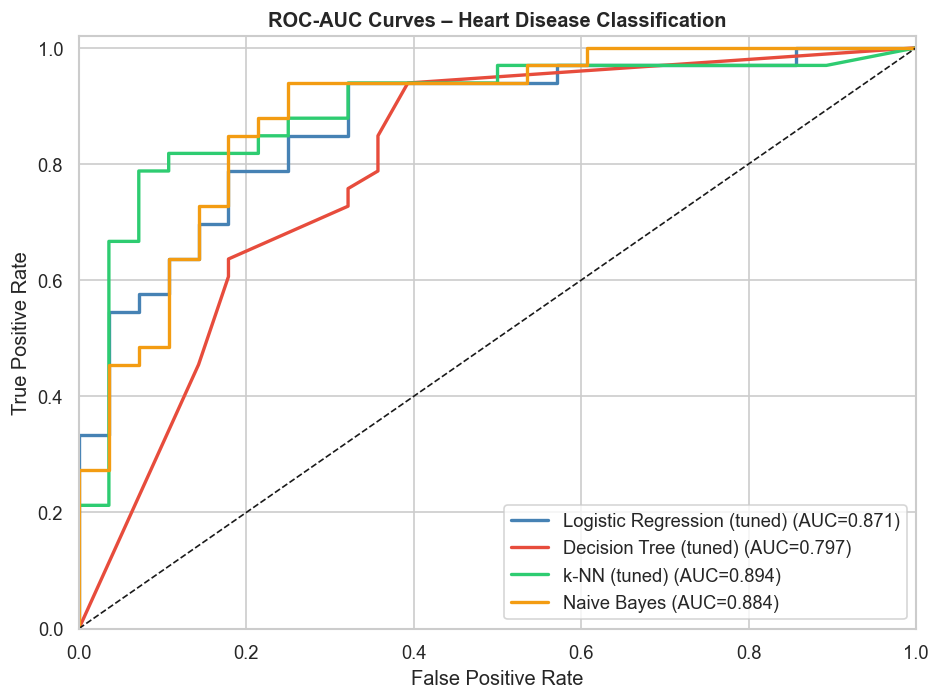

In [32]:
# ── ROC-AUC CURVES ──────────────────────────────────────────────────────────
# Plots True Positive Rate vs False Positive Rate at every threshold
# AUC = area under the curve — closer to 1.0 = better discrimination
# Diagonal dashed line = random classifier baseline (AUC = 0.5)
# ROC-AUC curves — all tuned models + Naive Bayes
roc_models = [
    (gs_lr.best_estimator_,  X_test_sc, 'Logistic Regression (tuned)'),
    (gs_dt.best_estimator_,  X_test,    'Decision Tree (tuned)'),
    (gs_knn.best_estimator_, X_test_sc, 'k-NN (tuned)'),
    (res_nb['model'],        X_test_sc, 'Naive Bayes'),
]
colors = ['steelblue', '#e74c3c', '#2ecc71', '#f39c12']

plt.figure(figsize=(8, 6))
for (model, X_te, name), color in zip(roc_models, colors):
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves – Heart Disease Classification', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

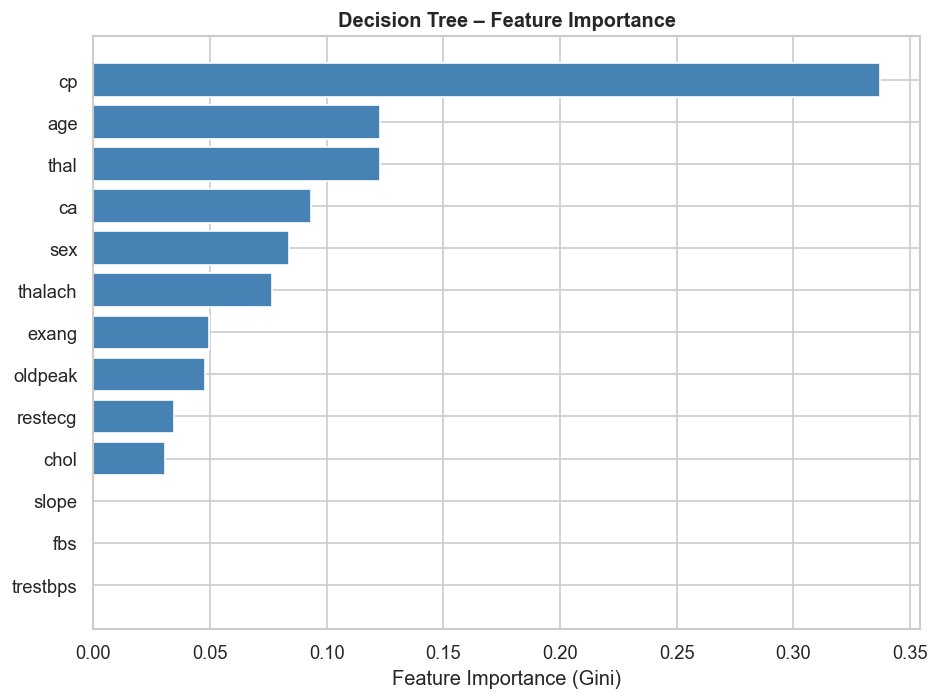

In [33]:
# ── FEATURE IMPORTANCE: DECISION TREE ───────────────────────────────────────
# Gini importance: how much each feature reduces impurity across all splits
# Higher bar = more important feature for predicting heart disease
# Only available for tree-based models
# Feature importance — tuned Decision Tree
importances = gs_dt.best_estimator_.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df.sort_values('Importance', ascending=True, inplace=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree – Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

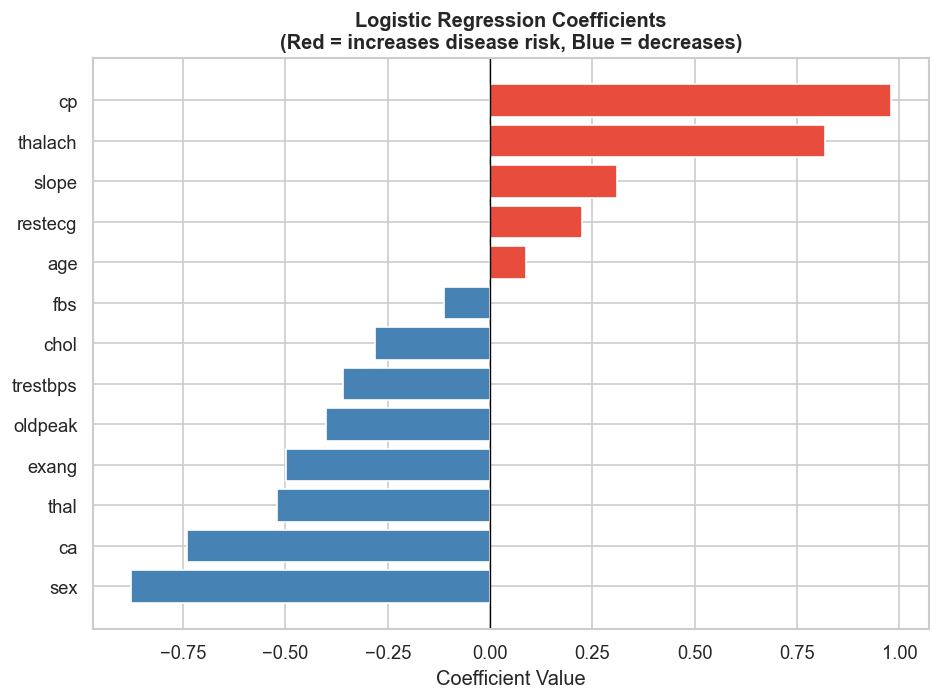

In [34]:
# ── LOGISTIC REGRESSION COEFFICIENTS ────────────────────────────────────────
# Each coefficient = the log-odds change in disease risk per unit increase
# Red bars = features that INCREASE disease probability
# Blue bars = features that DECREASE disease probability
# This is the most clinically interpretable output of all models
# Logistic Regression coefficients
best_lr = gs_lr.best_estimator_
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': best_lr.coef_[0]
}).sort_values('Coefficient')

colors_coef = ['#e74c3c' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients\n(Red = increases disease risk, Blue = decreases)', fontweight='bold')
plt.tight_layout()
plt.show()

##  Section 10 – Final Summary
Print the complete ranked results table with the prior work benchmark for reference.

In [35]:
# ── FINAL RESULTS PRINTOUT ──────────────────────────────────────────────────
# Prints the complete ranked model summary table
# Compare your best result to the PMC (2025) benchmark of 99% accuracy
# Final summary printout
print('=' * 65)
print('  FINAL RESULTS – HEART DISEASE CLASSIFICATION')
print('=' * 65)
print(summary_df.to_string(index=False))
print()

print('=' * 65)

  FINAL RESULTS – HEART DISEASE CLASSIFICATION
                      Model  Test Acc  F1-Score  ROC-AUC  CV Mean  CV Std
               k-NN (tuned)    0.8197    0.8358   0.8945   0.8504  0.0468
    Decision Tree (untuned)    0.8033    0.8182   0.8019   0.7801  0.0280
        Logistic Regression    0.8033    0.8235   0.8712   0.8379  0.0861
Logistic Regression (tuned)    0.8033    0.8235   0.8712   0.8379  0.0861
 k-Nearest Neighbors (k=11)    0.7869    0.8116   0.8777   0.8046  0.0476
                Naive Bayes    0.7869    0.7937   0.8842   0.8172  0.0489
      Decision Tree (tuned)    0.7049    0.7273   0.7971   0.8094  0.0570



This analysis applied four classification models to the UCI-derived Heart Disease dataset, achieving a best test accuracy of 81.97% and ROC-AUC of 0.8945 using a tuned k-NN classifier (manhattan distance, k=21, distance-weighted). Logistic Regression matched this accuracy at 80.33% while offering superior interpretability through its coefficients. Both models meaningfully exceeded the Naive Bayes baseline (78.69%) and the tuned Decision Tree (70.49%).

Compared to the PMC (2025) benchmark of 99% accuracy achieved with a Random Forest deep learning pipeline, our models fall short by approximately 17 percentage points. This gap reflects the expected performance ceiling of shallow classifiers on this dataset and underscores the value of ensemble methods and deep learning for clinical prediction tasks. However, the interpretability, low computational cost, and reasonable recall rates of our models make them viable candidates for low-resource or explainability-constrained clinical settings. Future improvements could include feature selection, ensemble methods such as Random Forest or Gradient Boosting, and calibration techniques to improve probability estimates for clinical threshold optimization.
